# 📊 Ejercicio Básico 1 — Análisis exploratorio de leyes de oro
### Mina Cerro Kori (región ficticia de Altomayo) · *Datos 100% simulados*

**Objetivo:** aprender a leer un archivo Excel con `pandas`, calcular estadísticas básicas y visualizar la distribución de leyes de oro (Au g/t) de una operación minera.

**Conceptos:** ley de cabeza, media vs mediana en distribuciones lognormales, estadística por zona de minado.

**Herramientas:** `pandas`, `matplotlib`

## 1. Cargar los datos
El archivo `01_leyes_mina_cerro_kori.xlsx` contiene 180 días de muestreo con: fecha, zona de minado, tonelaje y leyes de Au y Ag.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/01_leyes_mina_cerro_kori.xlsx", sheet_name="leyes_diarias")
df["fecha"] = pd.to_datetime(df["fecha"])
df.head()

,fecha,zona,tonelaje_tms,ley_au_g_t,ley_ag_g_t
0,2026-01-01,Tajo Sur,1909,4.29,45.9
1,2026-01-02,Tajo Norte,1660,2.71,27.0
2,2026-01-03,Subterranea Esperanza,1818,7.04,47.0
3,2026-01-04,Tajo Sur,1816,5.91,47.0
4,2026-01-05,Tajo Norte,1934,2.98,38.0


## 2. Inspección rápida
Antes de analizar, siempre revisamos el tamaño, los tipos de datos y si hay valores faltantes.

In [2]:
print("Filas y columnas:", df.shape)
print("\nValores faltantes por columna:")
print(df.isna().sum())
df.describe().round(2)

Filas y columnas: (180, 5)

Valores faltantes por columna:
fecha           0
zona            0
tonelaje_tms    0
ley_au_g_t      0
ley_ag_g_t      0
dtype: int64


,fecha,tonelaje_tms,ley_au_g_t,ley_ag_g_t
count,180,180.00,180.00,180.00
mean,2026-03-31 12:00:00,1847.54,4.10,41.52
min,2026-01-01 00:00:00,1198.00,1.47,11.20
25%,2026-02-14 18:00:00,1700.50,2.82,26.90
50%,2026-03-31 12:00:00,1857.50,3.74,36.95
75%,2026-05-15 06:00:00,1991.50,4.91,51.00
max,2026-06-29 00:00:00,2421.00,10.53,134.30
std,NaN,223.06,1.73,20.91


## 3. Estadísticas por zona de minado
Las leyes de oro suelen tener **distribución lognormal**: pocas muestras muy ricas "jalan" la media hacia arriba. Por eso comparamos **media vs mediana**.

In [3]:
resumen = df.groupby("zona").agg(
    dias=("ley_au_g_t", "size"),
    ley_au_media=("ley_au_g_t", "mean"),
    ley_au_mediana=("ley_au_g_t", "median"),
    ley_au_max=("ley_au_g_t", "max"),
    tonelaje_total=("tonelaje_tms", "sum"),
).round(2)
resumen

,dias,ley_au_media,ley_au_mediana,ley_au_max,tonelaje_total
zona,,,,,
Subterranea Esperanza,30,6.68,6.88,10.53,56803
Tajo Norte,81,3.05,2.86,6.32,149079
Tajo Sur,69,4.20,3.99,6.83,126676


> 💡 **Observación metalúrgica:** en las tres zonas la media es mayor que la mediana → distribución con cola a la derecha (lognormal), típico en yacimientos de oro.

## 4. Ley media ponderada por tonelaje
La ley promedio de la mina **no** es el promedio simple: cada día aporta distinto tonelaje. La ley correcta se pondera:

$$\bar{L} = \frac{\sum (T_i \times L_i)}{\sum T_i}$$

In [4]:
ley_simple = df["ley_au_g_t"].mean()
ley_ponderada = (df["tonelaje_tms"] * df["ley_au_g_t"]).sum() / df["tonelaje_tms"].sum()
print(f"Ley promedio simple    : {ley_simple:.2f} g/t")
print(f"Ley ponderada (correcta): {ley_ponderada:.2f} g/t")

Ley promedio simple    : 4.10 g/t
Ley ponderada (correcta): 4.11 g/t


## 5. Visualización

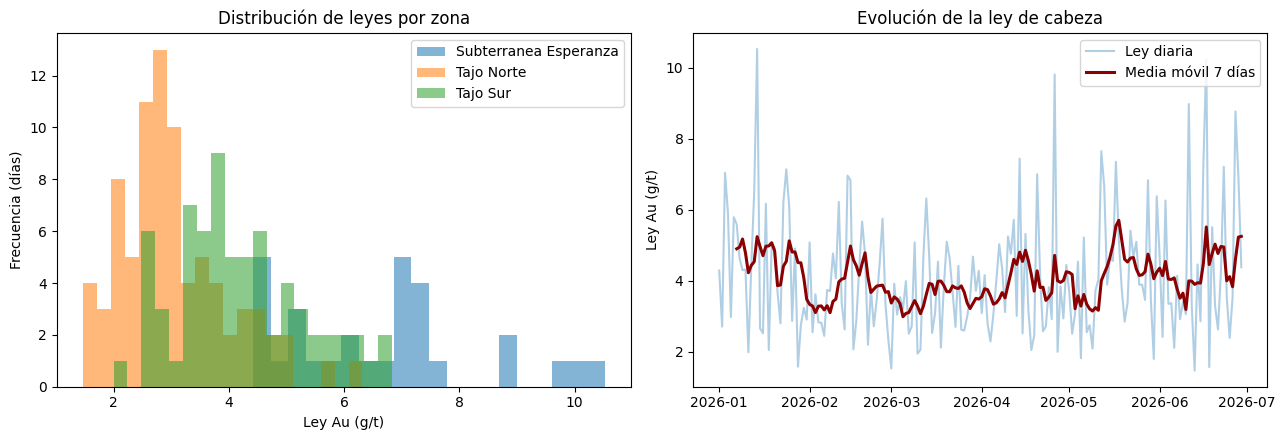

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histograma por zona
for zona, g in df.groupby("zona"):
    axes[0].hist(g["ley_au_g_t"], bins=20, alpha=0.55, label=zona)
axes[0].set_xlabel("Ley Au (g/t)"); axes[0].set_ylabel("Frecuencia (días)")
axes[0].set_title("Distribución de leyes por zona"); axes[0].legend()

# Serie de tiempo (media móvil 7 días)
serie = df.set_index("fecha")["ley_au_g_t"]
axes[1].plot(serie.index, serie, alpha=0.35, label="Ley diaria")
axes[1].plot(serie.rolling(7).mean(), lw=2.2, color="darkred", label="Media móvil 7 días")
axes[1].set_ylabel("Ley Au (g/t)"); axes[1].set_title("Evolución de la ley de cabeza")
axes[1].legend()
plt.tight_layout(); plt.show()

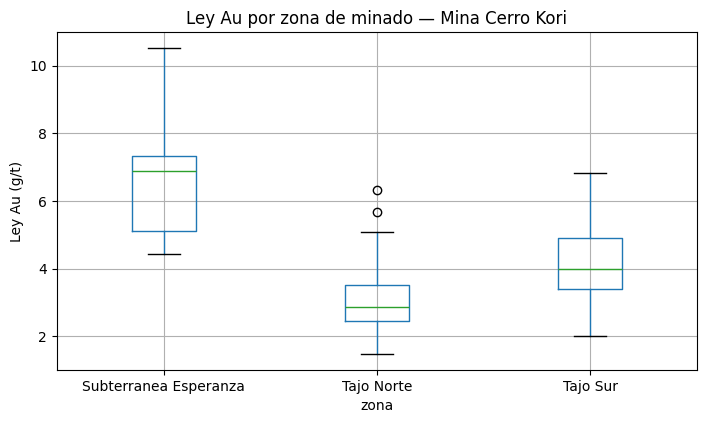

In [6]:
# Boxplot: la forma más rápida de comparar zonas
df.boxplot(column="ley_au_g_t", by="zona", figsize=(8, 4.5))
plt.suptitle(""); plt.title("Ley Au por zona de minado — Mina Cerro Kori")
plt.ylabel("Ley Au (g/t)"); plt.show()

## ✅ Conclusiones
1. La zona **Subterránea Esperanza** tiene la ley más alta (~6.5 g/t mediana) pero aporta menos tonelaje.
2. La ley ponderada por tonelaje es la métrica correcta para planeamiento y conciliación.
3. Las distribuciones son lognormales → usar mediana y percentiles, no solo la media.

**Siguiente paso:** [Ejercicio Básico 2 — Balance metalúrgico](02_basico_balance_metalurgico.ipynb)